In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("data.csv", )
pd.set_option('display.max_columns', None)

display(df.head())

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer City,Customer Country,Customer Id,Customer Segment,Customer State,Customer Zipcode,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,Order_Date,Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Name,Product Price,Product Status,Shipping_Date,Shipping Mode,Post_Order_Action,Transportation_Cost,Lead_Time,Supplier_ID
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,Sporting Goods,Caguas,Puerto Rico,20755,Consumer,PR,725.0,Fitness,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,20755,2018-01-31 22:56:00,77202,1360,13.110000,0.04,180517,327.75,0.29,1,327.75,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,Smart watch,327.75,0,2018-02-03 22:56:00,Standard Class,NaN,23.641850,6,sup001
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,Sporting Goods,Caguas,Puerto Rico,19492,Consumer,PR,725.0,Fitness,18.279451,-66.037064,Pacific Asia,Bikaner,India,19492,2018-01-13 12:27:00,75939,1360,16.389999,0.05,179254,327.75,-0.80,1,327.75,311.359985,-249.089996,South Asia,Rajastán,PENDING,NaN,1360,73,Smart watch,327.75,0,2018-01-18 12:27:00,Standard Class,NaN,18.305349,10,sup004
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,Sporting Goods,San Jose,EE. UU.,19491,Consumer,CA,95125.0,Fitness,37.292233,-121.881279,Pacific Asia,Bikaner,India,19491,2018-01-13 12:06:00,75938,1360,18.030001,0.06,179253,327.75,-0.80,1,327.75,309.720001,-247.779999,South Asia,Rajastán,CLOSED,NaN,1360,73,Smart watch,327.75,0,2018-01-17 12:06:00,Standard Class,NaN,21.521161,8,sup004
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,Sporting Goods,Los Angeles,EE. UU.,19490,Home Office,CA,90027.0,Fitness,34.125946,-118.291016,Pacific Asia,Townsville,Australia,19490,2018-01-13 11:45:00,75937,1360,22.940001,0.07,179252,327.75,0.08,1,327.75,304.809998,22.860001,Oceania,Queensland,COMPLETE,NaN,1360,73,Smart watch,327.75,0,2018-01-16 11:45:00,Standard Class,NaN,21.390399,6,sup002
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,Sporting Goods,Caguas,Puerto Rico,19489,Corporate,PR,725.0,Fitness,18.253769,-66.037048,Pacific Asia,Townsville,Australia,19489,2018-01-13 11:24:00,75936,1360,29.500000,0.09,179251,327.75,0.45,1,327.75,298.250000,134.210007,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,Smart watch,327.75,0,2018-01-15 11:24:00,Standard Class,NaN,26.171795,4,sup001


In [2]:
import pandas as pd
import numpy as np

# Convert order date to datetime
df['order date'] = pd.to_datetime(df['Order_Date'])

# Group by product and time period (e.g., month)
df.set_index('order date', inplace=True)
sales_by_product = df.groupby(['Product Card Id', pd.Grouper(freq='M')])['Sales'].sum().reset_index()
# Rename columns for clarity
sales_by_product.rename(columns={'Product Card Id': 'Product_Id', 'Sales': 'Total_Sales'}, inplace=True)

# Set 'Month' as index for further calculations
sales_by_product.set_index('order date', inplace=True)



# Calculate 'Lagged_Sales_1_Month'
sales_by_product['Lagged_Sales_1_Month'] = sales_by_product['Total_Sales'].shift(1)

# Shift the data by 1 to exclude the current month from the rolling average
sales_by_product['Rolling_Avg_Past_3_Months'] = sales_by_product['Total_Sales'].shift(1).rolling(window=3,min_periods=1).mean()


# Reset index to include 'Month' as a column again
sales_by_product.reset_index(inplace=True)

# Display the new DataFrame
display(sales_by_product) 


C:\Users\Admin\AppData\Local\Temp\ipykernel_12904\2985090380.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  sales_by_product = df.groupby(['Product Card Id', pd.Grouper(freq='M')])['Sales'].sum().reset_index()


,order date,Product_Id,Total_Sales,Lagged_Sales_1_Month,Rolling_Avg_Past_3_Months
0,2017-04-30,19,249.979996,NaN,NaN
1,2017-05-31,19,1624.869973,249.979996,249.979996
2,2017-06-30,19,1624.869973,1624.869973,937.424984
3,2017-07-31,19,1874.849969,1624.869973,1166.573314
4,2017-08-31,19,2124.829964,1874.849969,1708.196638
...,...,...,...,...,...
1813,2018-01-31,1361,3185.039989,2919.619990,39975.456663
1814,2017-12-31,1362,9063.000000,3185.039989,25195.886660
1815,2018-01-31,1362,24247.500000,9063.000000,5055.886660
1816,2017-12-31,1363,58703.041986,24247.500000,12165.179996


In [3]:
# Function to calculate outliers using IQR method
def calculate_outliers(df, column_name):
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column_name] < lower_bound) | (df[column_name] > upper_bound)]
    return len(outliers), (len(outliers) / len(df)) * 100

# Count outliers and percentage in each column
outliers_total_sales, pct_outliers_total_sales = calculate_outliers(sales_by_product, 'Total_Sales')
outliers_lagged_sales, pct_outliers_lagged_sales = calculate_outliers(sales_by_product, 'Lagged_Sales_1_Month')
outliers_rolling_avg, pct_outliers_rolling_avg = calculate_outliers(sales_by_product, 'Rolling_Avg_Past_3_Months')

# Display the results
outliers_info = {
    'Column': ['Total_Sales', 'Lagged_Sales_1_Month', 'Rolling_Avg_Past_3_Months'],
    'Outliers': [outliers_total_sales, outliers_lagged_sales, outliers_rolling_avg],
    'Percentage of Outliers (%)': [pct_outliers_total_sales, pct_outliers_lagged_sales, pct_outliers_rolling_avg]
}

outliers_df = pd.DataFrame(outliers_info)
outliers_df

,Column,Outliers,Percentage of Outliers (%)
0,Total_Sales,350,19.251925
1,Lagged_Sales_1_Month,349,19.196920
2,Rolling_Avg_Past_3_Months,357,19.636964


In [4]:
import numpy as np
import pandas as pd


# Function to calculate outliers using IQR method and return a boolean mask
def outlier_mask(df, column_name):
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (df[column_name] < lower_bound) | (df[column_name] > upper_bound)

# Create boolean masks for each column
total_sales_outlier_mask = outlier_mask(sales_by_product, 'Total_Sales')
lagged_sales_outlier_mask = outlier_mask(sales_by_product, 'Lagged_Sales_1_Month')
rolling_avg_outlier_mask = outlier_mask(sales_by_product, 'Rolling_Avg_Past_3_Months')

# Combine masks to check for rows with at least one outlier
combined_outlier_mask = total_sales_outlier_mask | lagged_sales_outlier_mask | rolling_avg_outlier_mask

# Count rows with at least one outlier
count_rows_with_outliers = combined_outlier_mask.sum()

# Calculate the percentage of rows with at least one outlier
percentage_rows_with_outliers = (count_rows_with_outliers / len(sales_by_product)) * 100

# Display the results
outliers_summary = {
    'Total Rows': len(sales_by_product),
    'Rows with at least one outlier': count_rows_with_outliers,
    'Percentage of Rows with at least one outlier (%)': percentage_rows_with_outliers
}

outliers_summary


{'Total Rows': 1818,
 'Rows with at least one outlier': 387,
 'Percentage of Rows with at least one outlier (%)': 21.287128712871286}

,order date,Product_Id,Total_Sales,Lagged_Sales_1_Month,Rolling_Avg_Past_3_Months
0,2017-04-30,19,5.521381,NaN,NaN
1,2017-05-31,19,7.393183,5.521381,5.521381
2,2017-06-30,19,7.393183,7.393183,6.843137
3,2017-07-31,19,7.536284,7.393183,7.061826
4,2017-08-31,19,7.661447,7.536284,7.443193
...,...,...,...,...,...
1813,2018-01-31,1361,8.066220,7.979209,10.596021
1814,2017-12-31,1362,9.111955,8.066220,10.134436
1815,2018-01-31,1362,10.096069,9.111955,8.528309
1816,2017-12-31,1363,10.980247,10.096069,9.406333


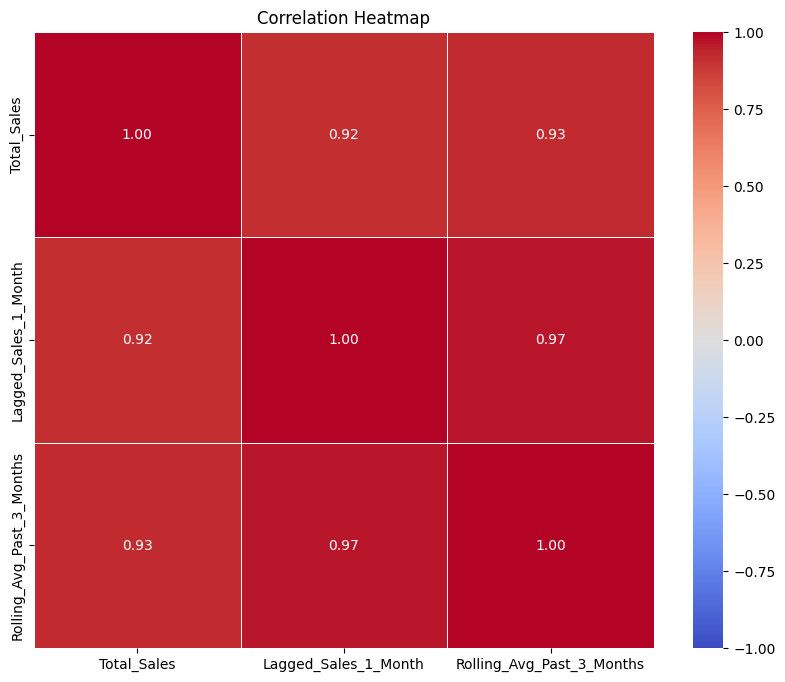

order date                   0
Product_Id                   0
Total_Sales                  0
Lagged_Sales_1_Month         1
Rolling_Avg_Past_3_Months    1
dtype: int64
order date                   0
Product_Id                   0
Total_Sales                  0
Lagged_Sales_1_Month         0
Rolling_Avg_Past_3_Months    0
dtype: int64


In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Applying log transformation to handle outliers
sales_by_product['Total_Sales'] = np.log(sales_by_product['Total_Sales'].replace(0, np.nan))
sales_by_product['Lagged_Sales_1_Month'] = np.log(sales_by_product['Lagged_Sales_1_Month'].replace(0, np.nan))
sales_by_product['Rolling_Avg_Past_3_Months'] = np.log(sales_by_product['Rolling_Avg_Past_3_Months'].replace(0, np.nan))


# Calculate correlation matrix
corr_matrix = sales_by_product[['Total_Sales', 'Lagged_Sales_1_Month', 'Rolling_Avg_Past_3_Months']].corr()
display(sales_by_product)
# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()
print(sales_by_product.isnull().sum())
sales_by_product.dropna(inplace=True)
print(sales_by_product.isnull().sum())


,Model,MSE,RMSE,R2,MAE
0,Linear Regression,0.517874,0.719634,0.878499,0.446834
1,Decision Tree,0.930213,0.964475,0.781758,0.600715
2,Random Forest,0.702253,0.838005,0.835241,0.525082
3,Support Vector Machine,0.539218,0.734315,0.873491,0.429115
4,Gradient Boosting,0.598476,0.773612,0.859589,0.451093


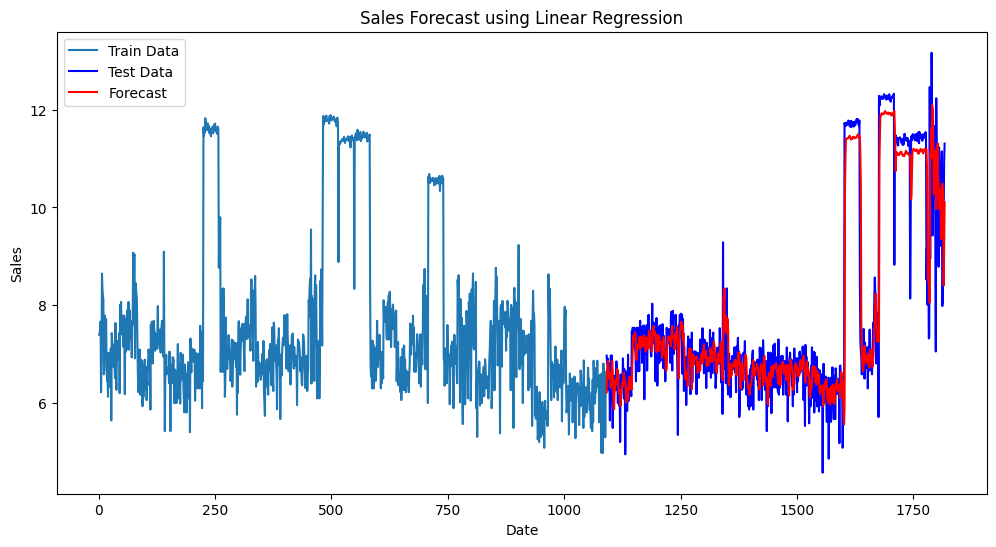

In [6]:

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

# Prepare Data
# Assuming sales_by_product is a DataFrame with 'Month', 'Total_Sales', and 'Rolling_Avg_Past_3_Months' columns
df = sales_by_product[['Total_Sales', 'Rolling_Avg_Past_3_Months','Lagged_Sales_1_Month']]

# Split Data
train_size = int(len(df) * 0.6)
train, test = df.iloc[:train_size], df.iloc[train_size:]

# Ensure there is enough data to build a meaningful model
if len(train) < 2:
    raise ValueError("Not enough data to build the model. Ensure the training set has enough data points.")

# Prepare the training and testing sets
X_train = train['Rolling_Avg_Past_3_Months'].values.reshape(-1, 1)
y_train = train['Total_Sales'].values
X_test = test['Rolling_Avg_Past_3_Months'].values.reshape(-1, 1)
y_test = test['Total_Sales'].values

# Define the models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor(),
    'Support Vector Machine': SVR(),
    'Gradient Boosting': GradientBoostingRegressor()
}

# Train and evaluate the models
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    forecast = model.predict(X_test)

    
    mse = mean_squared_error(y_test, forecast)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, forecast)
    mae = mean_absolute_error(y_test, forecast)
    
    results.append({
        'Model': name,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2,
        'MAE': mae
    })

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Display the results DataFrame
display(results_df)

# Plot Results for the best model
best_model_name = results_df.loc[results_df['R2'].idxmax()]['Model']
best_model = models[best_model_name]

forecast = best_model.predict(X_test)

plt.figure(figsize=(12, 6))
plt.plot(train.index, train['Total_Sales'], label='Train Data')
plt.plot(test.index, test['Total_Sales'], label='Test Data', color='blue')
plt.plot(test.index, forecast, label='Forecast', color='red')
plt.title(f'Sales Forecast using {best_model_name}')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()
